In [1]:
!pip install datasets


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

import pickle


from datasets import load_dataset


from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.preprocessing.sequence import pad_sequences


from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (

    Embedding,

    SimpleRNN,

    Dense,

    Dropout

)

c:\projects\TekWorks\Deep Learning\tfenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset = load_dataset(
    "ag_news"
)

train_df = dataset["train"].to_pandas()

test_df = dataset["test"].to_pandas()

c:\projects\TekWorks\Deep Learning\tfenv\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Chinnu\.cache\huggingface\hub\datasets--ag_news. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 7600/7600 [00:00<00:00, 482176.83 examples/s]


In [5]:
train_df.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [6]:
print(

    train_df.shape

)

print(

    test_df.shape

)

(120000, 2)
(7600, 2)


In [7]:
label_map = {

    0 : "World",

    1 : "Sports",

    2 : "Business",

    3 : "Sci/Tech"

}


train_df["category"] = train_df["label"].map(

    label_map

)

test_df["category"] = test_df["label"].map(

    label_map

)

In [8]:
train_df["category"].value_counts()

category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64

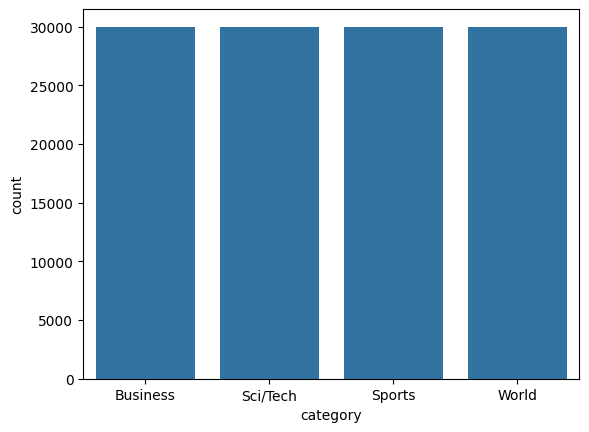

In [9]:
sns.countplot(

    x=train_df["category"]

)

plt.show()

In [10]:
vocab_size = 10000


tokenizer = Tokenizer(

    num_words=vocab_size,

    oov_token="<OOV>"

)


tokenizer.fit_on_texts(

    train_df["text"]

)

In [26]:
with open(

    "tokenizer.pkl",

    "wb"

) as f:

    pickle.dump(

        tokenizer,

        f

    )

In [11]:
X_train = tokenizer.texts_to_sequences(

    train_df["text"]

)


X_test = tokenizer.texts_to_sequences(

    test_df["text"]

)

In [12]:
max_length = 50


X_train = pad_sequences(

    X_train,

    maxlen=max_length,

    padding="post",

    truncating="post"

)


X_test = pad_sequences(

    X_test,

    maxlen=max_length,

    padding="post",

    truncating="post"

)

In [27]:
with open(

    "max_length.pkl",

    "wb"

) as f:

    pickle.dump(

        max_length,

        f

    )

In [13]:
y_train = train_df["label"]

y_test = test_df["label"]

In [14]:
print(

    X_train.shape

)

print(

    y_train.shape

)

print(

    X_test.shape

)

print(

    y_test.shape

)

(120000, 50)
(120000,)
(7600, 50)
(7600,)


In [15]:
model = Sequential([

    Embedding(

        input_dim=vocab_size,

        output_dim=128

    ),

    SimpleRNN(

        64

    ),

    Dropout(

        0.5

    ),

    Dense(

        32,

        activation="relu"

    ),

    Dense(

        4,

        activation="softmax"

    )

])

In [16]:
model.build(

    input_shape=(None,max_length)

)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,294,564 (4.94 MB)

 Trainable params: 1,294,564 (4.94 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [18]:
history = model.fit(

    X_train,

    y_train,

    epochs=5,

    batch_size=64,

    validation_split=0.2

)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.7498 - loss: 0.6642 - val_accuracy: 0.8326 - val_loss: 0.4893
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.8828 - loss: 0.3831 - val_accuracy: 0.8639 - val_loss: 0.4459
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.9026 - loss: 0.3301 - val_accuracy: 0.8838 - val_loss: 0.3596
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.9076 - loss: 0.3174 - val_accuracy: 0.8583 - val_loss: 0.4614
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.9006 - loss: 0.3481 - val_accuracy: 0.8439 - val_loss: 0.5861


In [19]:
loss,acc = model.evaluate(

    X_test,

    y_test

)

print(

    "Accuracy:",

    acc

)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8576 - loss: 0.5303
Accuracy: 0.8576315641403198


In [24]:
headline = [

    "United Nations discusses global climate change"

]


seq = tokenizer.texts_to_sequences(

    headline

)


pad = pad_sequences(

    seq,

    maxlen=max_length,

    padding="post"

)


prediction = model.predict(

    pad

)


label_map_rev = {

    0:"World",

    1:"Sports",

    2:"Business",

    3:"Sci/Tech"

}


print(

    label_map_rev[

        np.argmax(

            prediction

        )

    ]

)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
World


In [25]:
model.save(

    "ag_news_simplernn.keras"

)